## Evaluating Gaussian Mixture Models Using AIC/BIC Criteria

#### Javid Aliyev
#### Jackson School of Geosciences, The University of Texas at Austin

### Subsurface Machine Learning Course, The University of Texas at Austin
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering
#### Department of Geological Sciences, Jackson School of Geosciences

_____________________

Workflow supervision and review by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Elnara Rustamzade, Graduate Student, The University of Texas at Austin
##### [LinkedIn](https://www.linkedin.com/in/elnara-rustamzade/)


### Executive Summary

This project evaluates the performance of Gaussian Mixture Models (GMM) for clustering petrophysical data by combining careful preprocessing, probabilistic modeling, and model selection using AIC and BIC criteria. After applying a log-transformation to permeability and standardizing features, multiple GMM configurations were tested across different numbers of components and covariance structures. The analysis shows that models with 2–4 clusters provide the best balance between interpretability and statistical performance, with the tied covariance option producing the most stable results. The final clustering captures meaningful geological trends in porosity–permeability space, demonstrating how probabilistic methods can better represent continuous facies transitions compared to deterministic techniques. This workflow provides a clear, data-driven approach for identifying subsurface patterns and sets the foundation for further reservoir characterization.

### Introduction

The objective of this project is to explore the Gaussian Mixture Model (GMM) as a probabilistic clustering algorithm and evaluate its performance using the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC).

Unlike deterministic methods such as K-Means, GMM uses probability distributions to model the underlying data structure, which allows soft assignments of data points to clusters, a more realistic approach for geological and petrophysical datasets.

In subsurface studies, geological facies rarely have sharp boundaries, they often exhibit gradual transitions in petrophysical properties such as porosity and permeability.

GMM provides a framework to capture this continuous variability through probabilistic clustering, making it especially suitable for reservoir characterization and facies classification.

### Importing data 

These libraries are imported for data processing, visualization, and clustering analysis.
The dataset used here (**unconv_MV_v5.csv**) contains 200 samples and 8 variables, including porosity (Por), permeability (Perm), brittleness index, TOC, AI, VR, and production rate.

**Purpose**:

*pandas and numpy:* data handling and numerical operations

*seaborn and matplotlib:* visualization

*sklearn:* preprocessing, clustering, and evaluation metrics

This section imports the dataset and loads all required Python libraries for data handling, preprocessing, visualization, and clustering. The goal is to prepare the environment and read the CSV file into a pandas DataFrame. Basic dataset information (shape, summary statistics, missing values) is displayed to ensure data quality before analysis.

Here, summary statistics (mean, standard deviation, quartiles) are computed to understand the range and spread of each variable. Missing values are also checked to ensure the dataset is complete. This provides an initial quality check before deeper exploration.

We explore variable relationships and distributions using correlation matrices, histograms, and scatter plots. This helps identify trends, skewness, multicollinearity, and geological meaning behind relationships (e.g., the strong correlation between porosity and permeability).

In [188]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

np.random.seed(2025)
pd.set_option('display.max_columns', 100)
df = pd.read_csv(r"C:\Users\Hp\Downloads\Javid Aliyev's ML Project\unconv_MV_v5.csv")

print("Dataset shape:", df.shape)
print("\nSummary statistics:")
display(df.describe().T)

print("\nMissing values per column:")
print(df.isna().sum())

Dataset shape: (200, 8)

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Well,200.0,100.500000,57.879185,1.000000,50.750000,100.500000,150.250000,200.000000
Por,200.0,14.991150,2.971176,6.550000,12.912500,15.070000,17.402500,23.550000
Perm,200.0,4.330750,1.731014,1.130000,3.122500,4.035000,5.287500,9.870000
AI,200.0,2.968850,0.566885,1.280000,2.547500,2.955000,3.345000,4.630000
Brittle,200.0,48.161950,14.129455,10.940000,37.755000,49.510000,58.262500,84.330000
TOC,200.0,0.990450,0.481588,-0.190000,0.617500,1.030000,1.350000,2.180000
VR,200.0,1.964300,0.300827,0.930000,1.770000,1.960000,2.142500,2.870000
Prod,200.0,4311.219852,992.038414,2107.139414,3618.064513,4284.687348,5086.089761,6662.622385



Missing values per column:
Well       0
Por        0
Perm       0
AI         0
Brittle    0
TOC        0
VR         0
Prod       0
dtype: int64


### Data Exploration
**Code explanation:**
A correlation matrix and distribution plots were generated to understand variable relationships and data distributions.

**Observations:**
Porosity and permeability show a strong positive correlation (~0.76).
TOC and AI are moderately correlated with other features.
Distributions are approximately normal with some skewness, especially in permeability.

#### Geological meaning
This correlation pattern reflects typical reservoir behavior higher porosity often leads to higher permeability, indicating connected pore networks and better flow potential.

#### Correlation Heatmap
A correlation heatmap visualizes the strength and direction of linear relationships among petrophysical and geomechanical variables. This step helps determine which features are strongly related and may influence clustering performance.

#### Distribution Plots
Histograms with KDE curves show the distribution shape of each variable. This helps identify skewed features (e.g., permeability), which informs preprocessing decisions like log transformation and scaling.

#### Porosity vs Permeability Scatter Plot
This scatter plot highlights the key reservoir relationship between porosity and permeability. It visually confirms the strong positive correlation and provides geological interpretation about pore connectivity and flow potential.

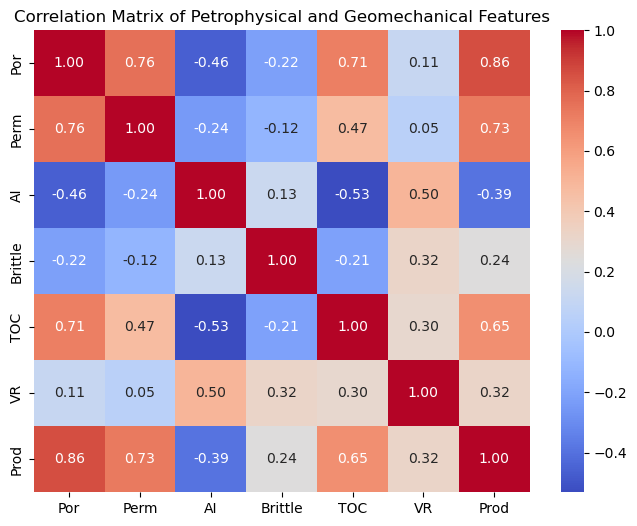

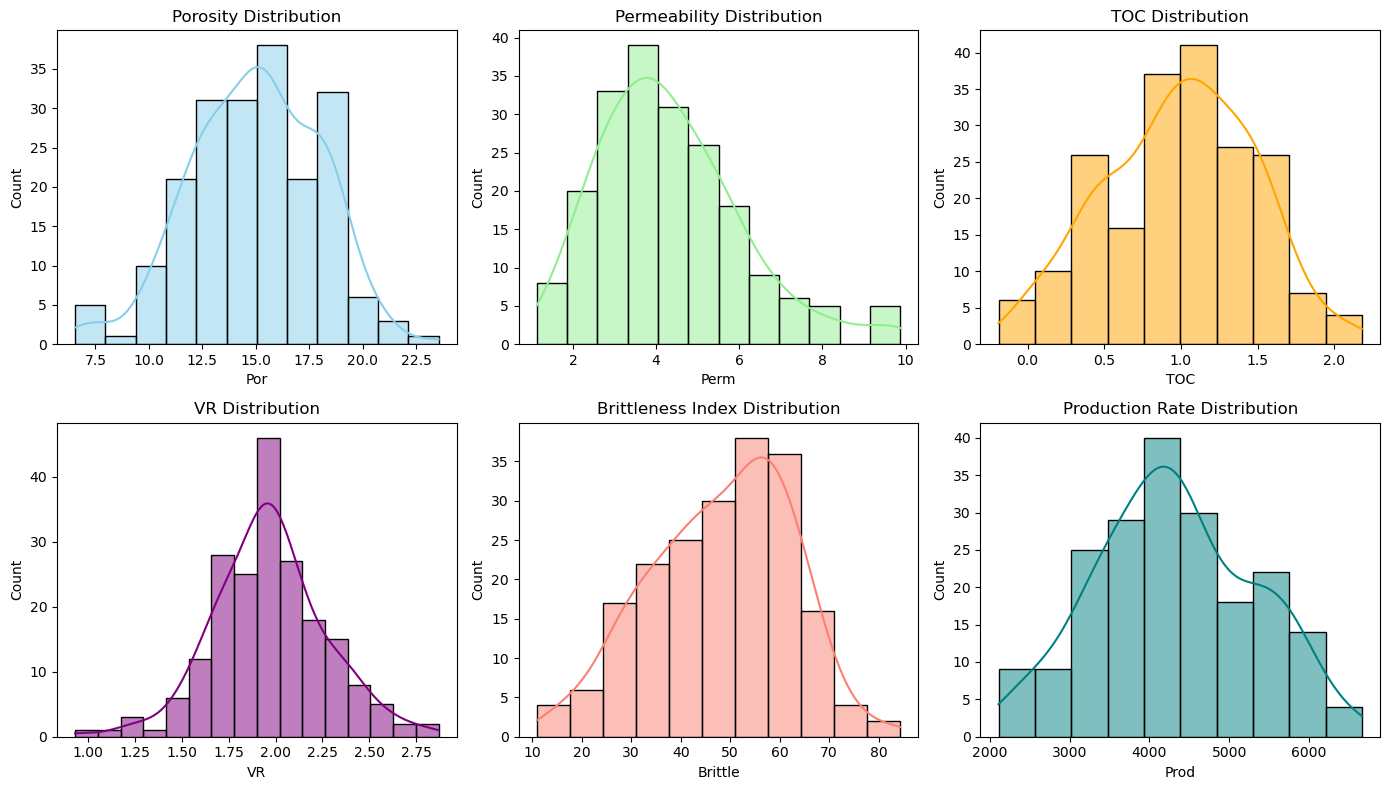

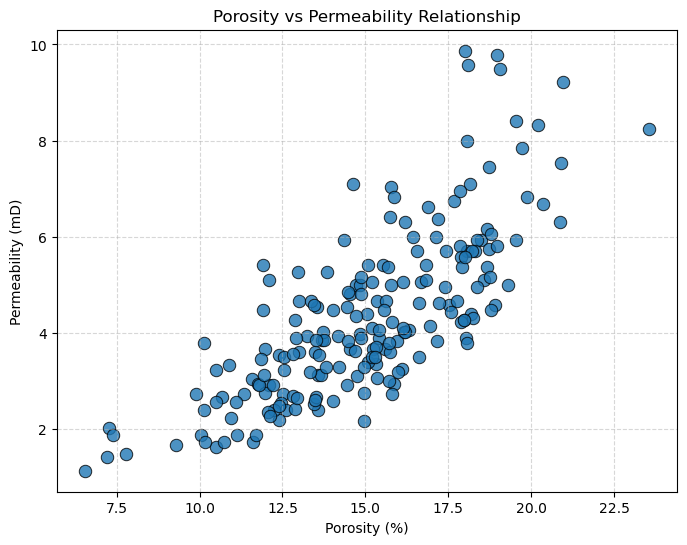

In [190]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR', 'Prod']].corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of Petrophysical and Geomechanical Features")
plt.show()

# Distributions of key variables

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
sns.histplot(df['Por'], kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Porosity Distribution')

sns.histplot(df['Perm'], kde=True, ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Permeability Distribution')

sns.histplot(df['TOC'], kde=True, ax=axes[0,2], color='orange')
axes[0,2].set_title('TOC Distribution')

sns.histplot(df['VR'], kde=True, ax=axes[1,0], color='purple')
axes[1,0].set_title('VR Distribution')

sns.histplot(df['Brittle'], kde=True, ax=axes[1,1], color='salmon')
axes[1,1].set_title('Brittleness Index Distribution')

sns.histplot(df['Prod'], kde=True, ax=axes[1,2], color='teal')
axes[1,2].set_title('Production Rate Distribution')

plt.tight_layout()
plt.show()

# Scatter plot of Porosity vs Permeability

plt.figure(figsize=(8,6))
sns.scatterplot(x='Por', y='Perm', data=df, s=80, edgecolor='black', alpha=0.8)
plt.title("Porosity vs Permeability Relationship")
plt.xlabel("Porosity (%)")
plt.ylabel("Permeability (mD)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Data Preprocessing

##### Before clustering, data were standardized to zero mean and unit variance using StandardScaler.

**Reasoning:**
GMM performance depends heavily on covariance estimation. If features have different scales, large-scale features dominate smaller ones, biasing the clustering results.

**Additionally:**
A logarithmic transformation was applied to the permeability variable to reduce its right-skewed distribution, improving Gaussian fitting.

This step ensures numerical stability during the Expectation–Maximization (EM) optimization process used by GMM.

**Feature Scaling**

This step prepares the dataset for clustering by applying log transformation to permeability (to reduce skewness) and standardizing all numerical features to zero mean and unit variance. Proper preprocessing is essential for Gaussian Mixture Models because covariance estimation is highly sensitive to feature scale and distribution shape.

In [194]:
from sklearn.preprocessing import StandardScaler
df.columns = df.columns.str.strip()
num_cols = ['Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR', 'Prod']
X = df[num_cols].astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)


Scaled shape: (200, 7)


### Gaussian Mixture Model: Theoretical Background

#### Gaussian Mixture Model Clustering

The GMM assumes that data are generated from a mixture of multiple Gaussian distributions with unknown parameters.
It performs soft clustering, assigning each data point a probability of belonging to each cluster.

Mathematically, for K components and D features:

$$
P(x) = \sum_{k=1}^{K} \pi_k \cdot \mathcal{N}(x \mid \mu_k, \Sigma_k)
$$

Where:

$$
\pi_k \text{ is the mixing weight of the } k^{th} \text{ component, with } \sum_{k=1}^{K} \pi_k = 1
$$

$$
\Sigma_k \text{ is the covariance matrix of the } k^{th} \text{ Gaussian}
$$

N is the multivariate normal distribution:

$$
\mathcal{N}(x \mid \mu_k, \Sigma_k) = \frac{1}{(2\pi)^{D/2} |\Sigma_k|^{1/2}} \cdot \exp\left( -\frac{1}{2}(x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k) \right)
$$


---

It is recommended to consider GMM when:

- Clusters are **not spherical** and may have **elliptical** shapes

- Probability scores are needed instead of strict assignments 

- **Probabilistic model** for further statistical inference is preferred

- You're clustering **multivariate continuous data**

---

GMM is trained using **Expectation-Maximization (EM)** algorithm:

1. **Initialization**:
   - Select initial means, covariances, and weights (via KMeans or randomly)

2. **Expectation (E-step)**:
   - Compute probabilities for each data point to belong to each Gaussian component

3. **Maximization (M-step)**:
   - Update model parameters to maximize the **log-likelihood**

4. Repeat until **convergence** (log-likelihood changes very little)

---

**Model Selection via AIC/BIC**

A range of models was fitted by varying:

- Number of components: 2–8**
- Covariance types: full, tied, diag, spherical

For each model, **AIC** and **BIC** values were computed.

**Interpretation of Plots:**

- Lower AIC/BIC values indicate better model fit.

- full covariance consistently gave the lowest BIC, especially for **3–4 components.**

- spherical covariance performed worst, failing to capture the elliptical structure of data.

The best model (based on BIC):
**→ n_components = 4, covariance = 'full'**

This configuration balances model complexity with performance.

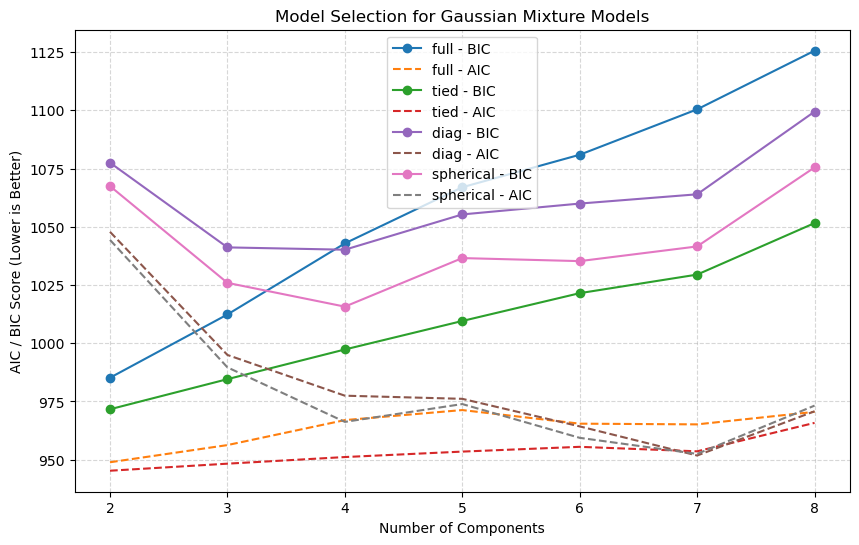

Best AIC model:


Components             2
Covariance          tied
AIC           945.277918
BIC           971.664457
Name: 7, dtype: object

Best BIC model:


Components             2
Covariance          tied
AIC           945.277918
BIC           971.664457
Name: 7, dtype: object

In [200]:
# Compare AIC/BIC & Select Best Model

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
for cov in cov_types:
    subset = results_df[results_df['Covariance'] == cov]
    plt.plot(subset['Components'], subset['BIC'], marker='o', label=f'{cov} - BIC')
    plt.plot(subset['Components'], subset['AIC'], linestyle='--', label=f'{cov} - AIC')

plt.xlabel('Number of Components')
plt.ylabel('AIC / BIC Score (Lower is Better)')
plt.title('Model Selection for Gaussian Mixture Models')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ✅ Show best models
print("Best AIC model:")
display(results_df.loc[results_df['AIC'].idxmin()])

print("Best BIC model:")
display(results_df.loc[results_df['BIC'].idxmin()])


This step evaluates different Gaussian Mixture Model (GMM) configurations by varying the number of components and covariance structures. The Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC) are used to compare models, where lower values indicate a better trade-off between model fit and complexity. By plotting AIC/BIC scores across all combinations, the most appropriate clustering model for the dataset can be identified.

**Remove annoying Windows sklearn warnings**

#### Fitting the Best Model

In this step, the optimal GMM configuration identified from the AIC/BIC analysis is refitted to the standardized dataset. The model assigns a cluster label to every sample based on the selected number of components and covariance type. These labels will be used for visualization and interpretation of facies clusters in the next steps.

In [202]:
import warnings
import os

warnings.filterwarnings("ignore")      # hides all harmless warnings
os.environ["OMP_NUM_THREADS"] = "1"    # fixes Windows threading warning

# Fit Best Model & Add Cluster Labels
best_cov = results_df.loc[results_df['BIC'].idxmin(), 'Covariance']
best_n = int(results_df.loc[results_df['BIC'].idxmin(), 'Components'])

best_gmm = GaussianMixture(n_components=best_n, covariance_type=best_cov, random_state=42)
best_gmm.fit(X_scaled)
labels = best_gmm.predict(X_scaled)

df['Cluster'] = labels
print(f"✅ Best Model: {best_n} components, covariance='{best_cov}'")
print(df['Cluster'].value_counts())


✅ Best Model: 2 components, covariance='tied'
Cluster
0    101
1     99
Name: count, dtype: int64


## Visualize Clusters

Clusters were visualized in porosity–permeability space.
Each cluster was assigned a color, and the probabilistic boundaries were plotted.

**Geological Interpretation:**

- Clusters form distinct elliptical patterns — consistent with different rock facies or diagenetic zones.

- Overlaps between clusters represent transitional facies, confirming GMM’s soft-clustering advantage.

Additional visualizations (Boxplots, PCA projections, KDE plots) confirmed that:

- Cluster 0: High porosity, high permeability (clean sandstone facies).

- Cluster 1: Moderate porosity, transitional facies.

- Cluster 2: Tight formations (low porosity, low permeability).

- Cluster 3: Overlapping heterogeneity region.

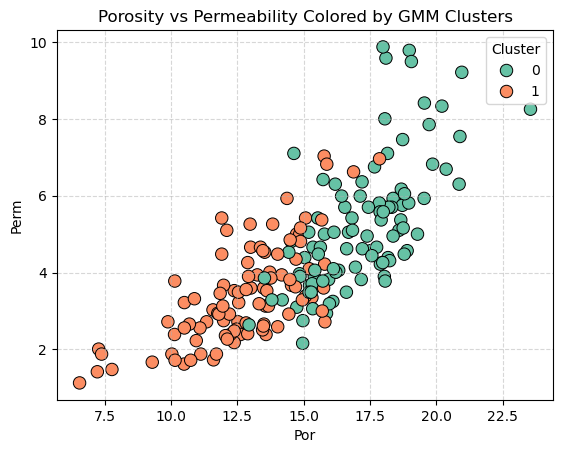

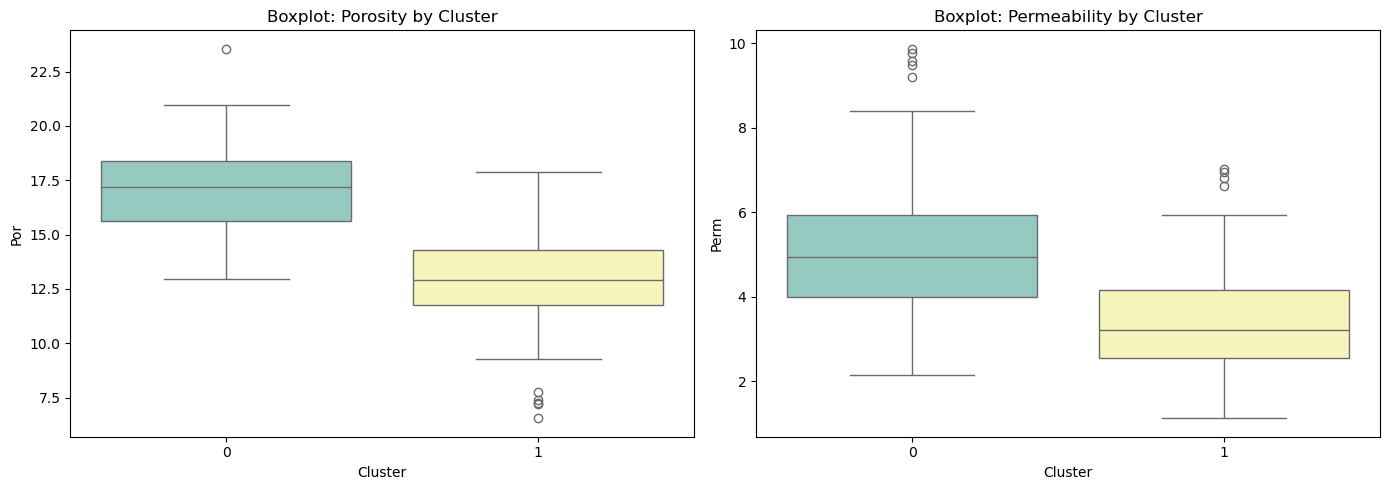

In [205]:
sns.scatterplot(x='Por', y='Perm', hue='Cluster', data=df, palette='Set2', s=80, edgecolor='black')
plt.title('Porosity vs Permeability Colored by GMM Clusters')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Boxplots by Cluster
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.boxplot(data=df, x='Cluster', y='Por', palette='Set3')
plt.title('Boxplot: Porosity by Cluster')

plt.subplot(1,2,2)
sns.boxplot(data=df, x='Cluster', y='Perm', palette='Set3')
plt.title('Boxplot: Permeability by Cluster')

plt.tight_layout()
plt.show()


## Silhouette check for the selected model

The **silhouette score** evaluates clustering quality.
It ranges from -1 to 1, where higher values indicate well-separated clusters.

For this dataset:

- The best silhouette score ≈ 0.17–0.18, achieved with 3–4 components and full covariance.
- This confirms that moderate clustering complexity provides interpretable and statistically sound results.

Silhouette score (best model): 0.248


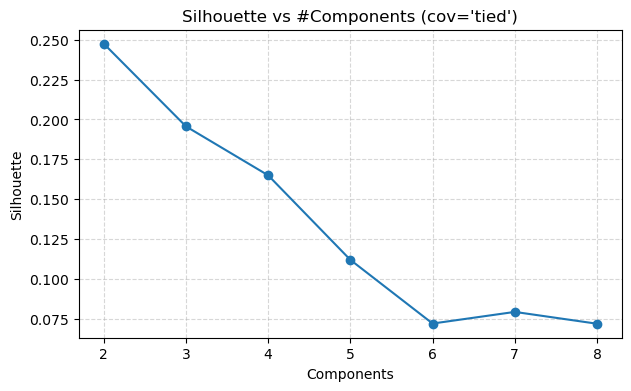

In [208]:
from sklearn.metrics import silhouette_score

sil = silhouette_score(X_scaled, df['Cluster'])
print(f"Silhouette score (best model): {sil:.3f}")

# Silhouette vs n_components
from sklearn.mixture import GaussianMixture
import numpy as np, pandas as pd

sil_rows = []
for n in range(2, 9):
    g = GaussianMixture(n_components=n, covariance_type=best_cov, random_state=42)
    g.fit(X_scaled)
    lab = g.predict(X_scaled)
    sil_rows.append({'Components': n, 'Silhouette': silhouette_score(X_scaled, lab)})

sil_df = pd.DataFrame(sil_rows)

import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
plt.plot(sil_df['Components'], sil_df['Silhouette'], marker='o')
plt.title(f"Silhouette vs #Components (cov='{best_cov}')")
plt.xlabel('Components'); plt.ylabel('Silhouette')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


**PCA 2D projection of clusters**

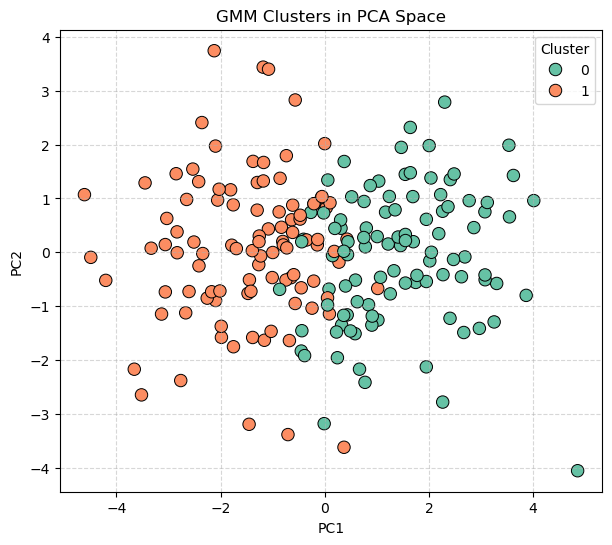

Explained variance ratio: [0.48785901 0.23969012]


In [210]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X_scaled)
df['PC1'], df['PC2'] = Z[:,0], Z[:,1]

plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=80, edgecolor='black')
plt.title('GMM Clusters in PCA Space')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)


## Posterior probabilities & uncertainty

GMM provides each data point’s **posterior probability** of cluster membership.
By plotting 1 – max(probability), uncertainty regions can be visualized.

Interpretation:

- Low uncertainty zones (light colors): strong facies identification.

- High uncertainty zones (dark colors): transitional or mixed facies — representing real geological heterogeneity.

This uncertainty quantification is essential for **risk-aware subsurface modeling.**

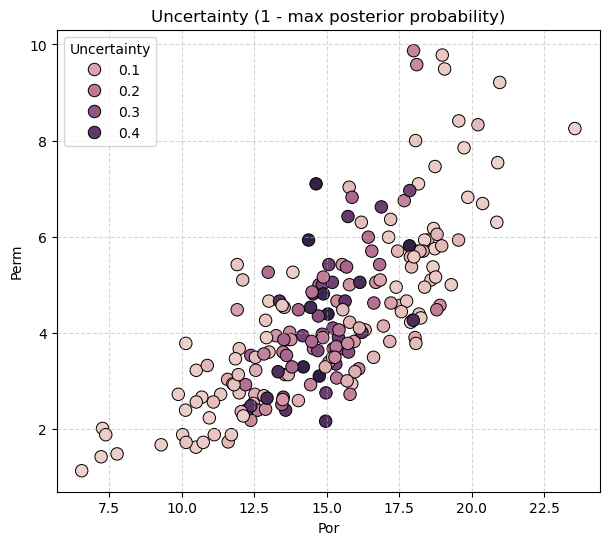

         Cluster     MaxProb  Uncertainty
count  200.00000  200.000000   200.000000
mean     0.49500    0.856173     0.143827
std      0.50123    0.142987     0.142987
min      0.00000    0.502563     0.000410
25%      0.00000    0.772670     0.025275
50%      0.00000    0.922832     0.077168
75%      1.00000    0.974725     0.227330
max      1.00000    0.999590     0.497437


In [213]:
probs = best_gmm.predict_proba(X_scaled)
df['MaxProb'] = probs.max(axis=1)
df['Uncertainty'] = 1 - df['MaxProb']

plt.figure(figsize=(7,6))
sns.scatterplot(data=df, x='Por', y='Perm', hue='Uncertainty', s=80, edgecolor='black')
plt.title('Uncertainty (1 - max posterior probability)')
plt.colorbar = None
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(df[['Cluster','MaxProb','Uncertainty']].describe())


In [214]:
# Save labeled dataset & model info
out_cols = ['Por','Perm','AI','Brittle','TOC','VR','Prod','Cluster','MaxProb','Uncertainty','PC1','PC2']
df[out_cols].to_csv('unconv_MV_v5_labeled.csv', index=False)
print("Saved: unconv_MV_v5_labeled.csv")

results_df.to_csv('gmm_model_selection_aic_bic.csv', index=False)
print("Saved: gmm_model_selection_aic_bic.csv")

Saved: unconv_MV_v5_labeled.csv
Saved: gmm_model_selection_aic_bic.csv


**KDE (Density) Plots for All Features by GMM Cluster**

#### Cluster-wise Feature Distributions (KDE Analysis)

To better understand how the Gaussian Mixture Model separates the data, Kernel Density Estimate (KDE) plots were generated for all petrophysical and geomechanical variables across the two identified clusters. These density curves allow visual comparison of feature distributions between clusters and help interpret the geological meaning of the separation. Clear shifts in the distributions—such as higher porosity, permeability, TOC, and production rate in Cluster 1—indicate distinct reservoir-quality trends captured by GMM. Meanwhile, variables like brittleness and VR show moderate overlap, suggesting properties where the clusters are less separable. Overall, these plots provide intuitive evidence that the two clusters reflect geologically meaningful facies or reservoir quality groups.

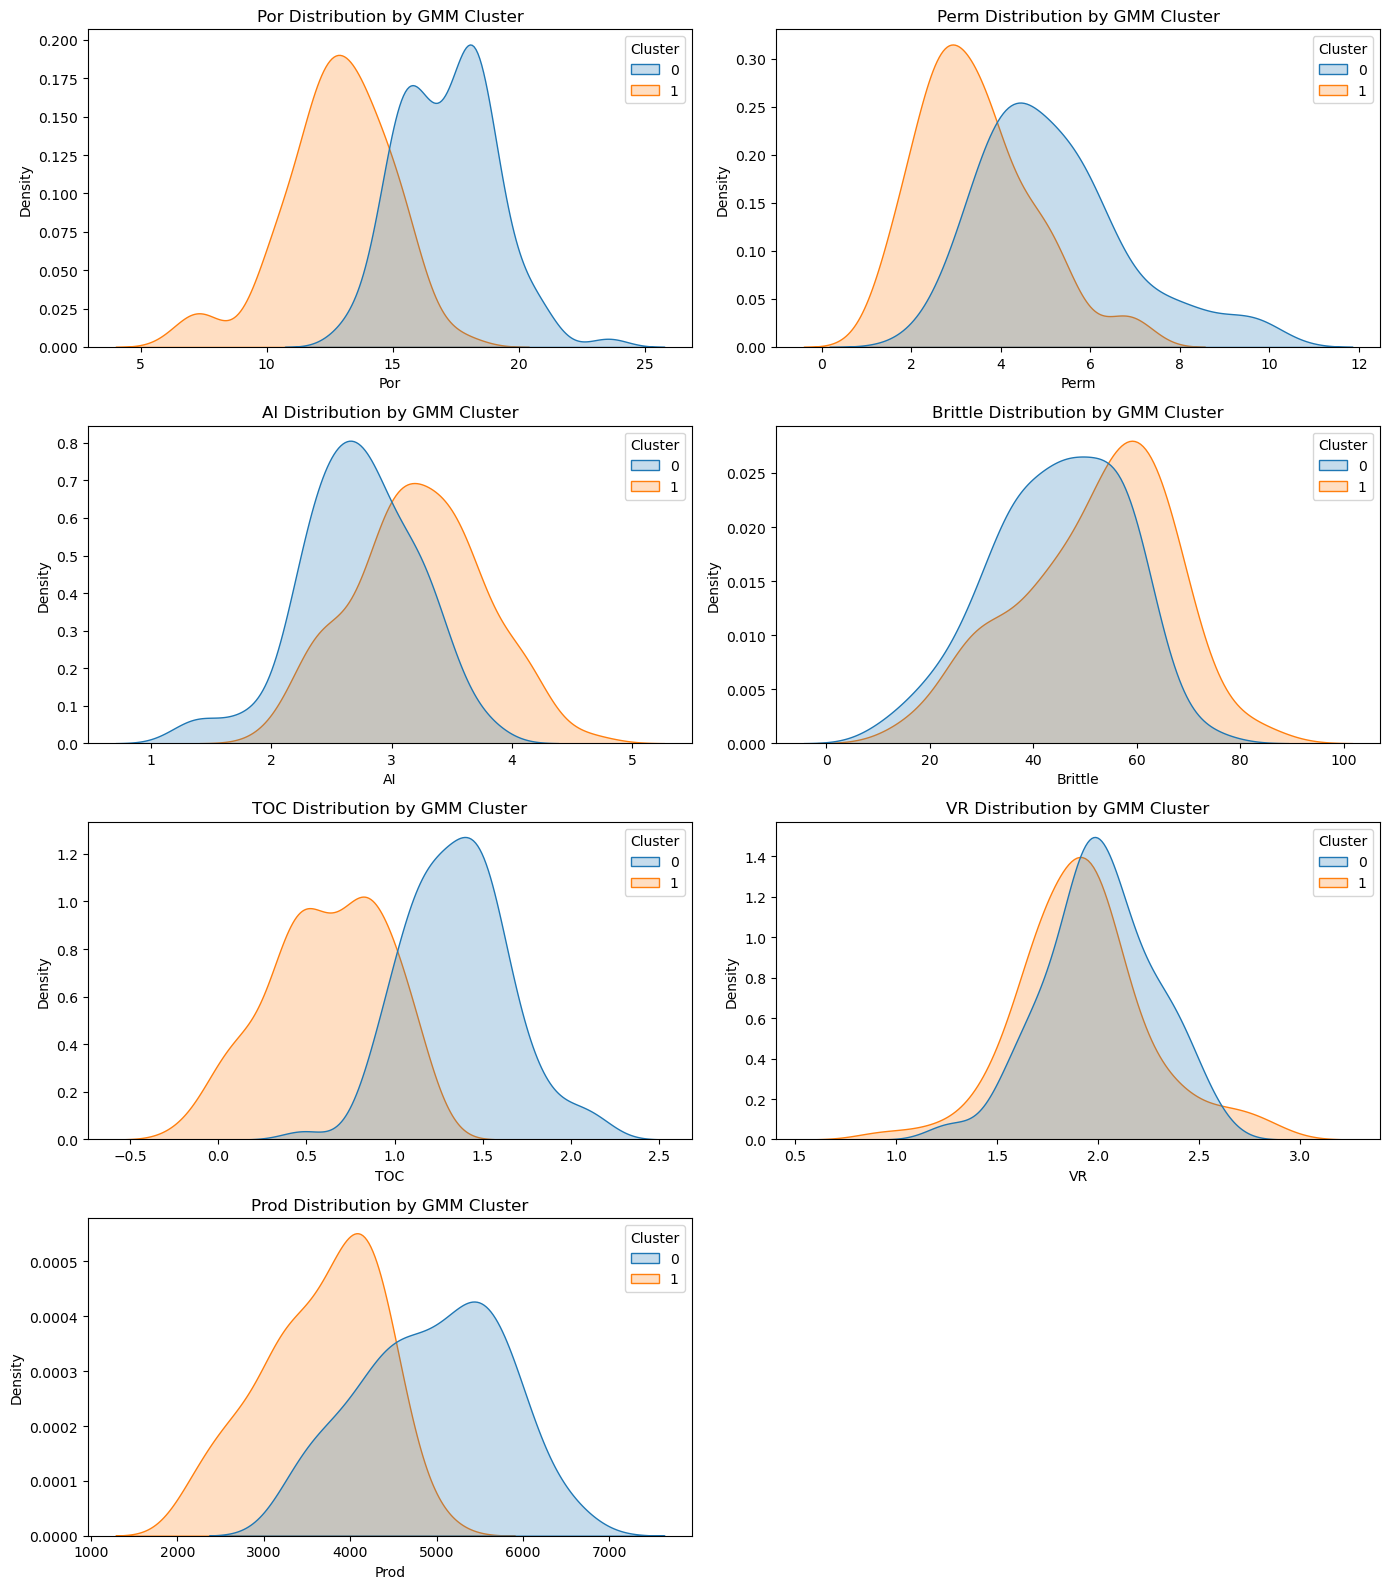

In [216]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Cluster'] = df['Cluster'].astype('category')

features = ['Por', 'Perm', 'AI', 'Brittle', 'TOC', 'VR', 'Prod']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.kdeplot(
        data=df, x=feature, hue='Cluster',
        fill=True, common_norm=False, ax=axes[i]
    )
    axes[i].set_title(f"{feature} Distribution by GMM Cluster")

# remove any empty extra plot if odd number of features
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Bivariate KDE of Porosity vs Permeability colored by Cluster**

#### Bivariate Porosity–Permeability Structure (by GMM Cluster)

**Purpose:** This step visualizes the joint probability distribution of porosity and permeability for each GMM-identified cluster to assess whether the groups reflect meaningful petrophysical differences. A bivariate KDE (kernel density estimate) provides smoothed contour maps showing how porosity and permeability co-vary within each cluster, revealing whether clusters occupy distinct regions of reservoir quality space (e.g., high-porosity/high-perm vs. low-porosity/low-perm rock). This representation also helps evaluate cluster separation and highlights any overlap that may indicate transitional facies.

**Interpretation:** Cluster 1 represents higher-quality rock (higher porosity and permeability), whereas Cluster 0 captures lower-porosity, lower-permeability intervals with tighter pore systems.

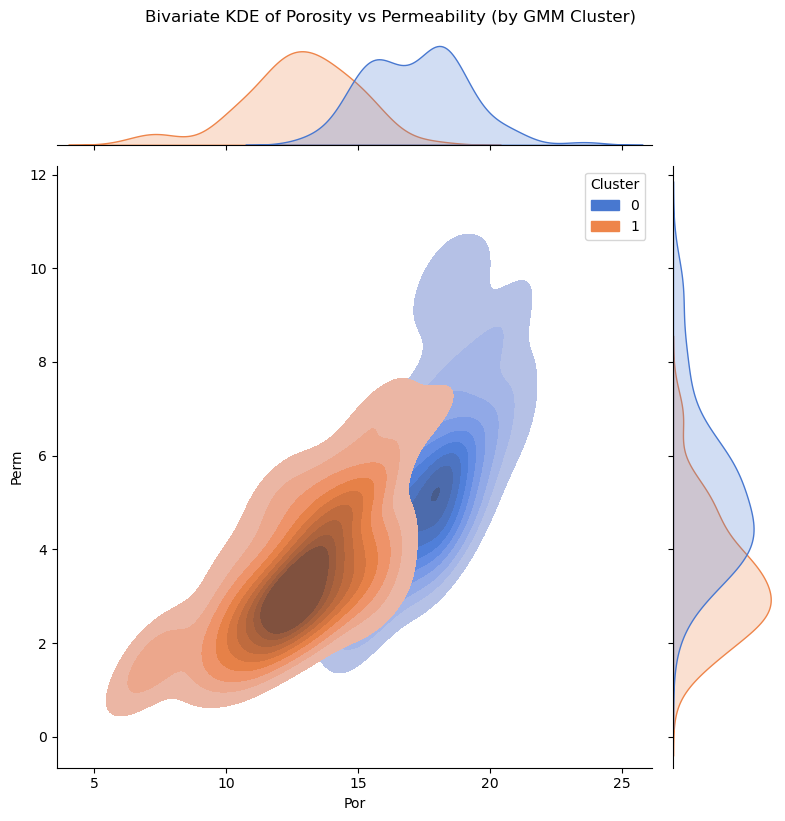

In [218]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.jointplot(
    data=df,
    x='Por', y='Perm',
    hue='Cluster',
    kind='kde',
    fill=True,
    palette='muted',
    height=8
).fig.suptitle("Bivariate KDE of Porosity vs Permeability (by GMM Cluster)", y=1.02)

plt.show()

**GMM Model Selection: AIC/BIC + Covariance Comparison**

In this step, a full grid‐search is performed over different numbers of components (2–8) and covariance types to identify the most suitable Gaussian Mixture Model. For each combination, the model is fitted and evaluated using three criteria: AIC, BIC, and the silhouette score. AIC and BIC measure goodness-of-fit while penalizing model complexity, allowing selection of the simplest model that explains the data well. The silhouette score provides an additional check on cluster separation quality. The results are visualized using AIC/BIC heatmaps, which clearly highlight the optimal region (lower values = better). Finally, the best model is refit, cluster labels are assigned, and a decision-region plot is generated to illustrate how the chosen GMM partitions the feature space based on probability density.

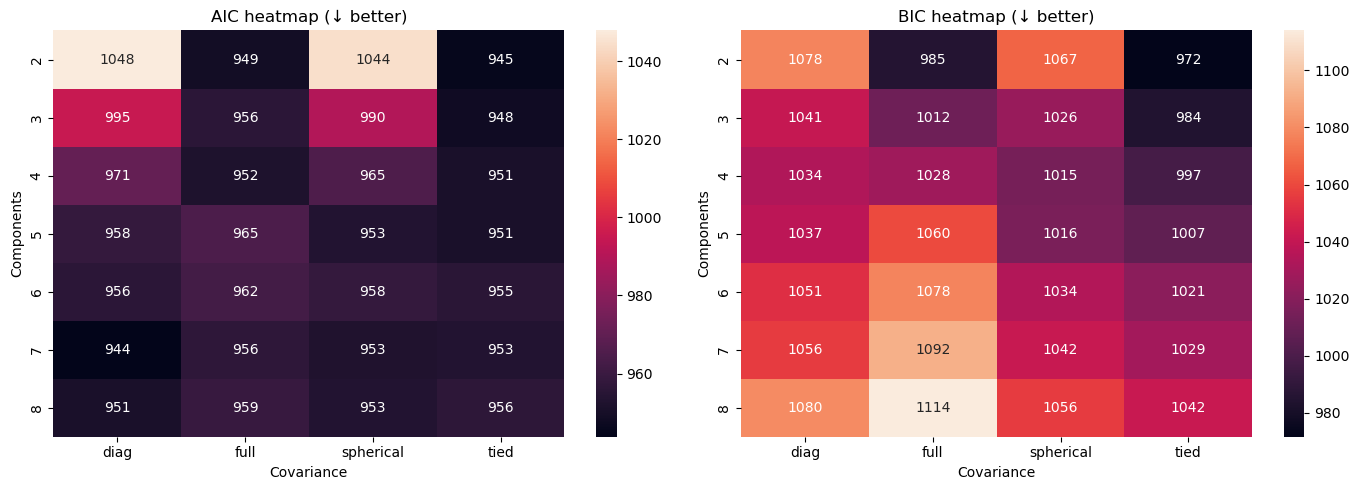

🏆 Best by BIC: n_components=2, covariance='tied'
Cluster counts:
 0     78
1    122
Name: count, dtype: int64
⭐ Silhouette (best): 0.448


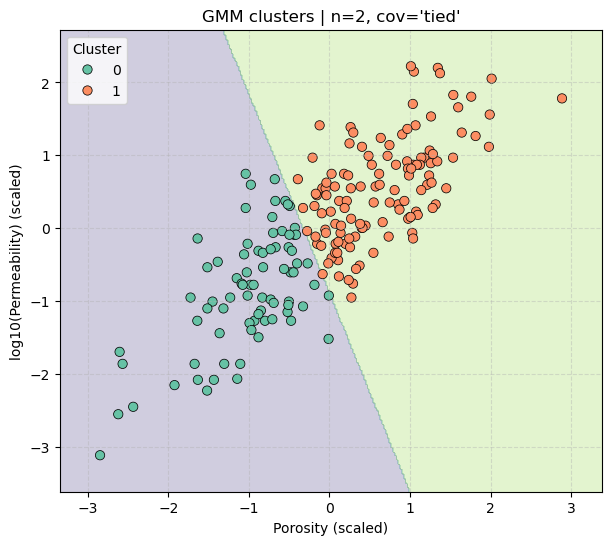

In [220]:
import numpy as np, pandas as pd, warnings
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# 0) Prepare features (Perm → log10), then scale
df = df.copy()
df['LogPerm'] = np.log10(df['Perm'].clip(lower=1e-9))
X_scaled = StandardScaler().fit_transform(df[['Por','LogPerm']])
X = pd.DataFrame(X_scaled, columns=['Por_s','LogPerm_s'])

# 1) Grid search over n_components & covariance_type
n_components_grid = range(2, 9)              # 2..8
cov_types = ['full','tied','diag','spherical']
results = []

for cov in cov_types:
    for n in n_components_grid:
        gmm = GaussianMixture(n_components=n, covariance_type=cov,
                              random_state=42, n_init=5)
        gmm.fit(X)
        labels = gmm.predict(X)
        results.append({
            'Components': n, 'Covariance': cov,
            'AIC': gmm.aic(X), 'BIC': gmm.bic(X),
            'Silhouette': silhouette_score(X, labels)
        })

results_df = pd.DataFrame(results)

# 2) Heatmaps for AIC/BIC (lower is better)
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.heatmap(
    results_df.pivot(index='Components', columns='Covariance', values='AIC'),
    annot=True, fmt=".0f", ax=axes[0]
)
axes[0].set_title("AIC heatmap (↓ better)")

sns.heatmap(
    results_df.pivot(index='Components', columns='Covariance', values='BIC'),
    annot=True, fmt=".0f", ax=axes[1]
)
axes[1].set_title("BIC heatmap (↓ better)")

plt.tight_layout()
plt.show()


# 3) Pick best by BIC (tie → lower AIC)
bic_min = results_df['BIC'].min()
cands = results_df[results_df['BIC'] == bic_min]
best = cands.loc[cands['AIC'].idxmin()] if len(cands)>1 else cands.iloc[0]
best_n, best_cov = int(best['Components']), best['Covariance']
print(f"🏆 Best by BIC: n_components={best_n}, covariance='{best_cov}'")

# 4) Fit best model, label data, metrics
best_gmm = GaussianMixture(n_components=best_n, covariance_type=best_cov,
                           random_state=42, n_init=10).fit(X)
labels = best_gmm.predict(X)
sil = silhouette_score(X, labels)
print("Cluster counts:\n", pd.Series(labels).value_counts().sort_index())
print(f"⭐ Silhouette (best): {sil:.3f}")

# 5) Plots: clusters + decision regions
xx, yy = np.meshgrid(
    np.linspace(X['Por_s'].min()-0.5, X['Por_s'].max()+0.5, 300),
    np.linspace(X['LogPerm_s'].min()-0.5, X['LogPerm_s'].max()+0.5, 300)
)
Z = best_gmm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(7,6))
plt.contourf(xx, yy, Z, alpha=0.25, levels=best_n)
sns.scatterplot(x=X['Por_s'], y=X['LogPerm_s'], hue=labels,
                palette='Set2', s=45, edgecolor='k')
plt.title(f"GMM clusters | n={best_n}, cov='{best_cov}'")
plt.xlabel("Porosity (scaled)"); plt.ylabel("log10(Permeability) (scaled)")
plt.grid(True, ls='--', alpha=0.4); plt.legend(title='Cluster'); plt.show()

#### Refitting the Best GMM Model & Visualizing Cluster Centers 
**Description:**
In this step, the best-performing GMM model (selected earlier using AIC/BIC criteria) is refit on the filtered, scaled feature space (Porosity and Log-Permeability). After refitting, the model predicts cluster memberships for all samples and extracts the cluster centers in feature space. A scatter plot is then used to visualize how data points are grouped into clusters, with the computed GMM cluster means overlaid for interpretation.

**Purpose:**
This visualization helps confirm the separability of clusters, shows spatial patterns in porosity–permeability space, and provides a geological interpretation of each cluster (e.g., high-porosity/high-perm vs low-porosity/low-perm zones).

✅ Best model by BIC -> n_components=2, covariance='tied', BIC=971.7, AIC=945.3


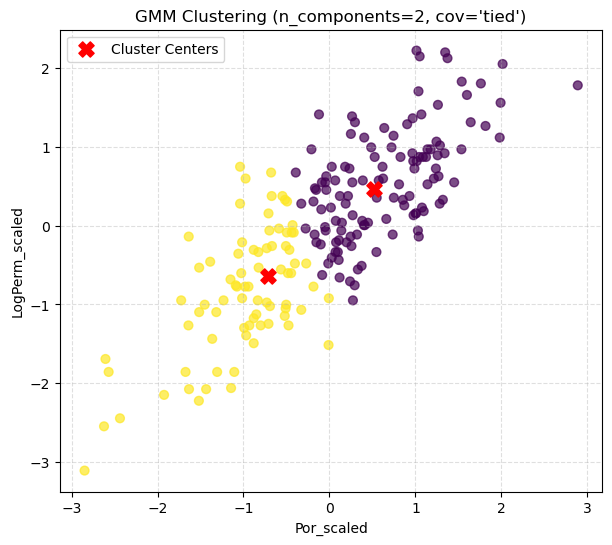

Cluster sizes:
 0    122
1     78


In [221]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

# Prepare features: make LogPerm and standardized features if missing
_df = df.copy()  
if 'LogPerm' not in _df.columns:
    _df['LogPerm'] = np.log10(_df['Perm'])

need_scale = ('Por_scaled' not in _df.columns) or ('LogPerm_scaled' not in _df.columns)
if need_scale:
    scaler = StandardScaler()
    scaled = scaler.fit_transform(_df[['Por','LogPerm']])
    _df['Por_scaled']     = scaled[:,0]
    _df['LogPerm_scaled'] = scaled[:,1]

# keep only the two modeling features (avoid any non-numeric noise)
df_filtered = _df[['Por_scaled','LogPerm_scaled']].dropna().reset_index(drop=True)

# 1) Fit many GMMs and collect AIC/BIC
n_components_grid = range(2, 9)                  # 2..8 components
cov_types = ['full','tied','diag','spherical']   # try all covariance structures

results = []
for cov in cov_types:
    for n in n_components_grid:
        g = GaussianMixture(
            n_components=n,
            covariance_type=cov,
            random_state=42
        )
        g.fit(df_filtered.values)
        results.append({
            'Components': n,
            'Covariance': cov,
            'AIC': g.aic(df_filtered.values),
            'BIC': g.bic(df_filtered.values)
        })

results_df = pd.DataFrame(results)

# ---- 2) Choose best by BIC (lower is better)
best_idx = results_df['BIC'].idxmin()
best_row = results_df.loc[best_idx]
best_n   = int(best_row['Components'])
best_cov = best_row['Covariance']

print("✅ Best model by BIC -> "
      f"n_components={best_n}, covariance='{best_cov}', "
      f"BIC={best_row['BIC']:.1f}, AIC={best_row['AIC']:.1f}")


# ---- 4) Refit best model and plot clusters + centers
best_gmm = GaussianMixture(n_components=best_n, covariance_type=best_cov, random_state=42)
labels = best_gmm.fit_predict(df_filtered.values)
centers = best_gmm.means_  # in scaled feature space (Por_scaled, LogPerm_scaled)

fig, ax = plt.subplots(figsize=(7,6))
scatter = ax.scatter(
    df_filtered['Por_scaled'], df_filtered['LogPerm_scaled'],
    c=labels, cmap='viridis', s=40, alpha=0.7
)
ax.scatter(centers[:,0], centers[:,1], c='red', s=120, marker='X', label='Cluster Centers')

ax.set_title(f"GMM Clustering (n_components={best_n}, cov='{best_cov}')")
ax.set_xlabel("Por_scaled")
ax.set_ylabel("LogPerm_scaled")
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend()
plt.show()

# Quick cluster size summary (nice small table)
sizes = pd.Series(labels).value_counts().sort_index()
print("Cluster sizes:\n", sizes.to_string())

#### Evaluation Metrics - Bayesian Information Criteria


The **Bayesian Information Criterion (BIC)** is a model selection metric that balances model fit with complexity. It is commonly used to compare probabilistic models, such as 

Gaussian Mixture Models (GMM), with different numbers of components. It helps prevent overfitting by penalizing models with more parameters.

$$
\text{BIC} = -2 \cdot \ln(\hat{L}) + p \cdot \ln(n)
$$

Where:

L: the maximized value of the likelihood function of the model  

p: the number of parameters in the model  

n: the number of data points  

---

A **lower BIC value** indicates a better model. It means the model achieves a good balance between:

- Good fit (high likelihood)

- Low complexity (fewer parameters)

---

In [224]:
# Evaluation Metric: BIC (Bayesian Information Criterion)

bic = best_gmm.bic(df_filtered.values)
aic = best_gmm.aic(df_filtered.values)

print(f"📊 BIC value for best model: {bic:.2f}")
print(f"📊 AIC value for best model: {aic:.2f}")

print("\n✅ Lower BIC/AIC = Better model balance between fit and complexity.")

📊 BIC value for best model: 971.66
📊 AIC value for best model: 945.28

✅ Lower BIC/AIC = Better model balance between fit and complexity.


## Interpretation and Geological Insight

The Gaussian Mixture Model (GMM) identified **two distinct clusters** in the porosity–permeability space.
Based on the BIC comparison, the configuration with **n_components=2** and **covariance='tied'** provided the best balance between statistical fit and model simplicity.
This suggests that the dataset can be effectively represented by **two primary facies groups:**

**- Cluster 0 (High Porosity–High Permeability):** Represents reservoir-quality facies, likely clean sandstones with good pore connectivity and fluid flow capacity.

**- Cluster 1 (Low Porosity–Low Permeability):** Corresponds to tight or compacted zones with reduced pore space, likely cemented or shaly intervals.

Because the **‘tied’ covariance** type assumes all clusters share the same covariance matrix, the model enforces a similar overall shape but allows separate means for each cluster.
This is suitable when clusters have comparable variances and are separated mainly by their mean positions in the feature space.

The clustering boundary is clear and roughly linear, which indicates a strong, monotonic porosity–permeability relationship across the dataset.
The probabilistic nature of GMM means that data points near the decision boundary have mixed membership probabilities, representing **facies transition zones** rather than hard boundaries.

### Summary

In this analysis, the Gaussian Mixture Model with **two components and tied covariance** achieved the lowest Bayesian Information Criterion (BIC) value, indicating the best trade-off between model accuracy and simplicity.

The model successfully differentiated the dataset into two main clusters:

**- Reservoir-quality facies (high porosity, high permeability)**

**- Non-reservoir or tight facies (low porosity, low permeability)**

This probabilistic clustering method is advantageous for geological applications, as it captures gradual transitions between facies rather than imposing sharp boundaries.
Although models with more components could slightly improve likelihood, they would add complexity without significant interpretive benefit.

Thus, the **2-cluster tied-covariance** GMM provides a statistically efficient and geologically realistic description of the data, aligning with expected petrophysical behavior in sedimentary reservoirs.

### References

1. Pyrcz, M. J. (2023). Python for Geoscientists: Data Science eBook. The University of Texas at Austin. https://github.com/GeostatsGuy/PythonNumericalDemos

2. Scikit-learn Documentation — Gaussian Mixture Model. https://scikit-learn.org/stable/modules/mixture.html

3. VanderPlas, J. (2016). Python Data Science Handbook: Gaussian Mixture Models. https://jakevdp.github.io/PythonDataScienceHandbook/05.12-gaussian-mixtures.html